Loading data...
Loaded 500000 rows

Feature Columns Used:
['p90_processor_time', 'avg_processor_time', 'max_cpu_usage', 'avg_memory_utilization', 'max_memory_usage', 'avg_battery_health', 'cpu_count', 'memory_size_gb', 'avg_cpu_temp', 'p90_boot_time', 'uptime_days', 'total_app_crash']

Training records: 14285

Training Random Forest Regressor...

=== AVG BOOT TIME PREDICTION PERFORMANCE ===
MSE: 586.91
MAE: 2.79 seconds
R²: 0.201

Top Predictors of Avg Boot Time:
                   feature  importance
9            p90_boot_time    0.877837
3   avg_memory_utilization    0.020486
8             avg_cpu_temp    0.019738
6                cpu_count    0.017227
1       avg_processor_time    0.016270
10             uptime_days    0.011715
11         total_app_crash    0.011561
4         max_memory_usage    0.008414
5       avg_battery_health    0.007598
2            max_cpu_usage    0.004763
0       p90_processor_time    0.003896
7           memory_size_gb    0.000496

=== HIGH AVG BOOT TIME D

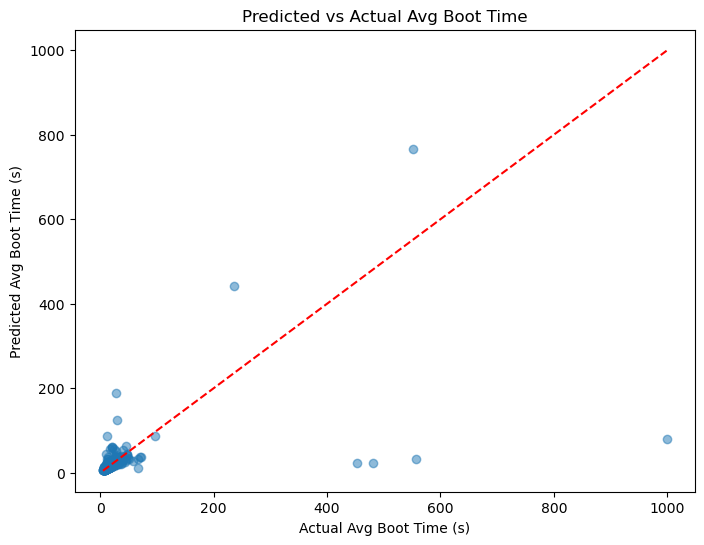

In [ ]:
#relevance of some features is questionable but can remove later, too direct correlation to P90
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import gzip
import warnings
warnings.filterwarnings('ignore')

print("Loading data...")

columns = [
    'karl_id', 'host_name', 'model_name', 'hardware_make', 'karl_last_seen',
    'auth_username', 'serial_number', 'group_id', 'tenant_id', 'platform',
    'metric_category', 'measure_name', 'time', 'p90_processor_time',
    'avg_processor_time', 'max_cpu_usage', 'p90_memory_utilization',
    'avg_memory_utilization', 'max_memory_usage', 'p10_battery_health',
    'avg_battery_health', 'cpu_count', 'memory_count', 'memory_size_gb',
    'driver_vendor', 'os', 'wifi_mac_add', 'driver_version', 'driver_date',
    'os_version', 'driver', 'agent_id', 'performance_status', 'device_status',
    'max_battery_temperature', 'avg_battery_temperature', 'p90_battery_temperature',
    'avg_cpu_temp', 'p90_cpu_temp', 'avg_battery_discharge', 'p90_battery_discharge',
    'avg_boot_time', 'p90_boot_time', 'uptime_days', 'total_app_crash'
]

chunk_size = 100000
sample_data = []
with gzip.open('000.gz', 'rt') as f:
    for i, chunk in enumerate(pd.read_csv(f, sep='|', names=columns, chunksize=chunk_size)):
        sample_data.append(chunk)
        if i >= 4:
            break

df = pd.concat(sample_data, ignore_index=True)

numeric_cols = [
    'avg_processor_time', 'p90_processor_time', 'max_cpu_usage',
    'avg_memory_utilization', 'max_memory_usage', 'avg_battery_health',
    'cpu_count', 'memory_size_gb', 'avg_cpu_temp', 'avg_boot_time',
    'p90_boot_time', 'uptime_days', 'total_app_crash'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f"Loaded {len(df)} rows")

feature_cols = [
    'p90_processor_time','avg_processor_time','max_cpu_usage',
    'avg_memory_utilization','max_memory_usage','avg_battery_health',
    'cpu_count','memory_size_gb','avg_cpu_temp','p90_boot_time',
    'uptime_days','total_app_crash'
]

print("\nFeature Columns Used:")
print(feature_cols)

model_df = df[feature_cols + ['avg_boot_time']].dropna()
print(f"\nTraining records: {len(model_df)}")

X = model_df[feature_cols]
y = model_df['avg_boot_time']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nTraining Random Forest Regressor...")

rf_model = RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)

rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n=== AVG BOOT TIME PREDICTION PERFORMANCE ===")
print(f"MSE: {mse:.2f}")
print(f"MAE: {mae:.2f} seconds")
print(f"R²: {r2:.3f}")

importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop Predictors of Avg Boot Time:")
print(importance)

high_boot_threshold = model_df['avg_boot_time'].quantile(0.90)
actual_high_risk = y_test >= high_boot_threshold
pred_high_risk = y_pred >= high_boot_threshold
risk_accuracy = (actual_high_risk == pred_high_risk).mean()

print("\n=== HIGH AVG BOOT TIME DETECTION ===")
print(f"Threshold: {high_boot_threshold:.2f} seconds")
print(f"Detection Accuracy: {risk_accuracy:.3f}")

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.xlabel("Actual Avg Boot Time (s)")
plt.ylabel("Predicted Avg Boot Time (s)")
plt.title("Predicted vs Actual Avg Boot Time")
plt.show()